# Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 12})

# Paths and data loading

In [ ]:
base_dir = Path.cwd()
results_dir = base_dir / 'results'

fl_metrics_path = results_dir / 'fl_metrics.json' 
hosp_a_path = results_dir / 'coordinator_hospital_a_metrics.json'
hosp_b_path = results_dir / 'coordinator_hospital_b_metrics.json'
hosp_c_path = results_dir / 'coordinator_hospital_c_metrics.json'

fl_df = pd.read_json(fl_metrics_path)

hosp_a_df = pd.read_json(hosp_a_path)
hosp_b_df = pd.read_json(hosp_b_path)
hosp_c_df = pd.read_json(hosp_c_path)

fl_df.head(3)

,round_num,wall_time_s,aggregation_time_s,max_client_compute_s,total_upload_mb,total_download_mb,auroc_macro,f1_macro,recall_macro,precision_macro,val_loss,mia_vulnerability,bandwidth_efficiency,client_stats
0,1,91.252753,0,908.617730,90.861504,90.861504,0.667932,0.097907,0.086793,0.213474,0.093869,0.562500,0.003676,"[{'client_id': '343574.0', 'round_num': 1, 'co..."
1,2,88.719963,0,478.639206,90.861504,90.861504,0.714776,0.102979,0.109548,0.182956,0.091850,0.560547,0.000258,"[{'client_id': '343574.0', 'round_num': 2, 'co..."
2,3,92.121411,0,888.111963,90.861504,90.861504,0.742896,0.132764,0.136352,0.196521,0.088687,0.566406,0.000155,"[{'client_id': '343574.0', 'round_num': 3, 'co..."


# Preprocessing

In [ ]:
def extract_client_stats(df, hospital_name):
    """Extracts nested dictionary stats from the client_stats column."""
    records = []
    for _, row in df.iterrows():
        stats = row['client_stats'][0] 
        records.append({
            'round_num': row['round_num'],
            'train_loss': stats['train_loss'],
            'compute_time_s': stats['compute_time_s'],
            'num_examples': stats['num_examples'],
            'hospital': hospital_name
        })
    return pd.DataFrame(records)

# Unnest and concatenate all hospital data
df_a = extract_client_stats(hosp_a_df, 'Hospital A')
df_b = extract_client_stats(hosp_b_df, 'Hospital B')
df_c = extract_client_stats(hosp_c_df, 'Hospital C')

train_df = pd.concat([df_a, df_b, df_c], ignore_index=True)
train_df.head()

,round_num,train_loss,compute_time_s,num_examples,hospital
0,1,0.120484,908.617730,9286,Hospital A
1,2,0.101455,478.639206,9286,Hospital A
2,3,0.096904,888.111963,9286,Hospital A
3,4,0.093785,975.609179,9286,Hospital A
4,5,0.090804,810.282180,9286,Hospital A


# Global convergence

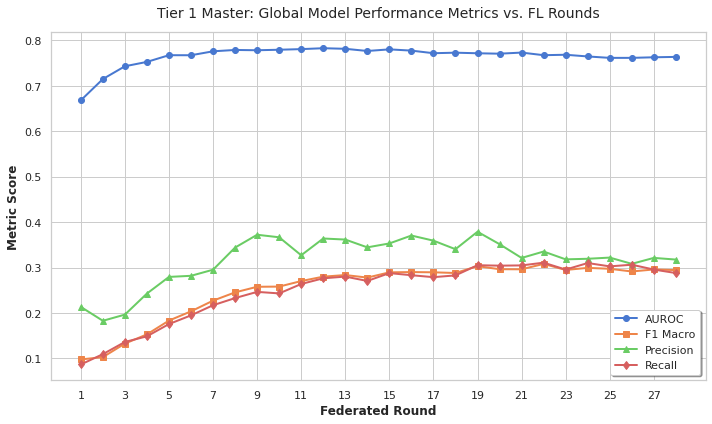

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(fl_df['round_num'], fl_df['auroc_macro'], label='AUROC', marker='o', linewidth=2)
plt.plot(fl_df['round_num'], fl_df['f1_macro'], label='F1 Macro', marker='s', linewidth=2)
plt.plot(fl_df['round_num'], fl_df['precision_macro'], label='Precision', marker='^', linewidth=2)
plt.plot(fl_df['round_num'], fl_df['recall_macro'], label='Recall', marker='d', linewidth=2)

plt.xlabel('Federated Round', fontweight='bold')
plt.ylabel('Metric Score', fontweight='bold')
plt.title('Tier 1 Master: Global Model Performance Metrics vs. FL Rounds', fontsize=14, pad=15)
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.xticks(range(1, fl_df['round_num'].max() + 1, 2))
plt.tight_layout()
plt.show()

# Local Training Loss

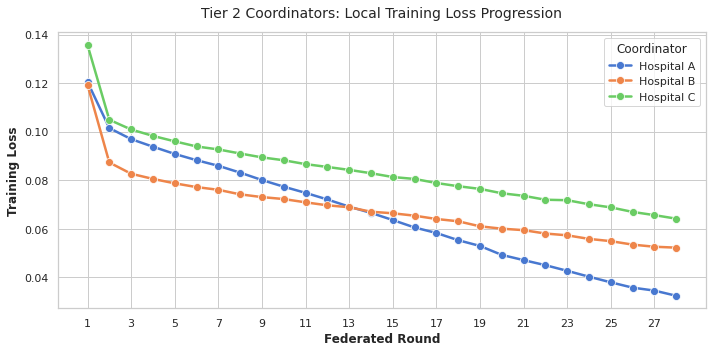

In [ ]:
plt.figure(figsize=(10, 5))

sns.lineplot(data=train_df, x='round_num', y='train_loss', hue='hospital', 
             marker='o', linewidth=2.5, markersize=8)

plt.xlabel('Federated Round', fontweight='bold')
plt.ylabel('Training Loss', fontweight='bold')
plt.title('Tier 2 Coordinators: Local Training Loss Progression', fontsize=14, pad=15)
plt.legend(title='Coordinator', frameon=True)
plt.xticks(range(1, fl_df['round_num'].max() + 1, 2))
plt.tight_layout()
plt.show()

# Compute time and Overheads

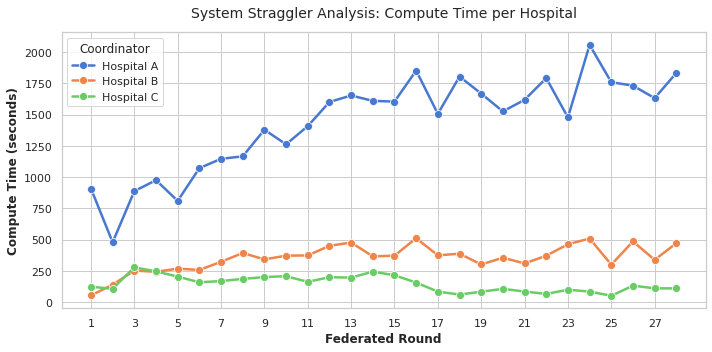

Dataset Sizes by Hospital:
hospital
Hospital A    9286
Hospital B    4689
Hospital C    4583
Name: num_examples, dtype: int64


In [ ]:
plt.figure(figsize=(10, 5))

sns.lineplot(data=train_df, x='round_num', y='compute_time_s', hue='hospital', 
             marker='o', linewidth=2.5, markersize=8)

plt.xlabel('Federated Round', fontweight='bold')
plt.ylabel('Compute Time (seconds)', fontweight='bold')
plt.title('System Straggler Analysis: Compute Time per Hospital', fontsize=14, pad=15)
plt.legend(title='Coordinator', frameon=True)
plt.xticks(range(1, fl_df['round_num'].max() + 1, 2))
plt.tight_layout()
plt.show()

print("Dataset Sizes by Hospital:")
print(train_df.groupby('hospital')['num_examples'].first())

# MIA vs convergence

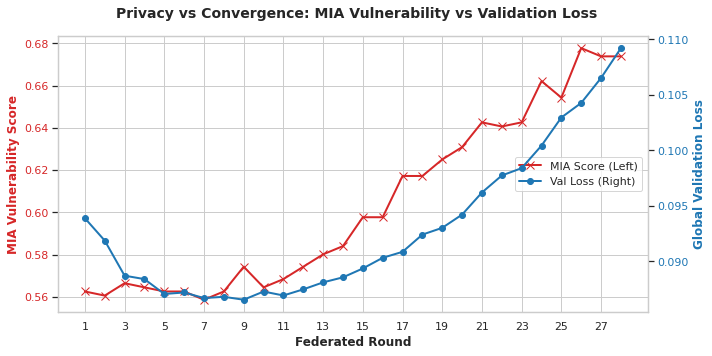

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color = '#d62728'
ax1.set_xlabel('Federated Round', fontweight='bold')
ax1.set_ylabel('MIA Vulnerability Score', color=color, fontweight='bold')
l1 = ax1.plot(fl_df['round_num'], fl_df['mia_vulnerability'], color=color, marker='x', 
              linewidth=2, markersize=8, label='MIA Score (Left)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(range(1, fl_df['round_num'].max() + 1, 2))

ax2 = ax1.twinx()
color = '#1f77b4'
ax2.set_ylabel('Global Validation Loss', color=color, fontweight='bold')
l2 = ax2.plot(fl_df['round_num'], fl_df['val_loss'], color=color, marker='o', 
              linewidth=2, markersize=6, label='Val Loss (Right)')
ax2.tick_params(axis='y', labelcolor=color)

# Combine legends
lines = l1 + l2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')

fig.suptitle('Privacy vs Convergence: MIA Vulnerability vs Validation Loss', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.grid(False, axis='y') # Disable secondary gridlines
plt.show()